In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns


In [3]:
df = pd.read_excel(r"C:\Users\Aman Kumar Singh\Desktop\Text_Analytics\text_analytics_cwk\cwk_train_data.xlsx")

In [4]:
pf = pd.read_excel(r"C:\Users\Aman Kumar Singh\Desktop\Text_Analytics\text_analytics_cwk\cwk_test_data.xlsx")

In [5]:
train_documents = df["Documents"].to_numpy()

In [6]:
test_documents = pf["Documents"].to_numpy()

In [7]:
docs = np.concatenate((train_documents, test_documents))


In [8]:
docs.shape

(4641,)

In [9]:
import spacy

nlp = spacy.load("en_core_web_sm")

all_sentences = []

for doc_text in docs:
    doc = nlp(doc_text)
    sentences = [sent.text.strip() for sent in doc.sents]
    all_sentences.extend(sentences)
    
print(len(sentences))

c:\Users\Aman Kumar Singh\anaconda3\envs\text_analytics\Lib\site-packages\spacy\util.py:910: UserWarning: [W095] Model 'en_core_web_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.5). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


24


In [23]:
len(all_sentences)

51969

In [10]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [11]:
sentence_embeddings = model.encode(all_sentences)

print(type(sentence_embeddings))
print(sentence_embeddings.shape)

<class 'numpy.ndarray'>
(51969, 384)


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(sentence_embeddings)

In [35]:
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(X_scaled)
cluster_labels = kmeans.labels_
#score = silhouette_score(sentence_embeddings, labels)



In [36]:
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(sentence_embeddings)

In [37]:
embeddings_2d.shape

(51969, 2)

In [38]:
temp_df = pd.DataFrame({"PC1": embeddings_2d[:,0], "PC2": embeddings_2d[:,1], "Labels": cluster_labels})

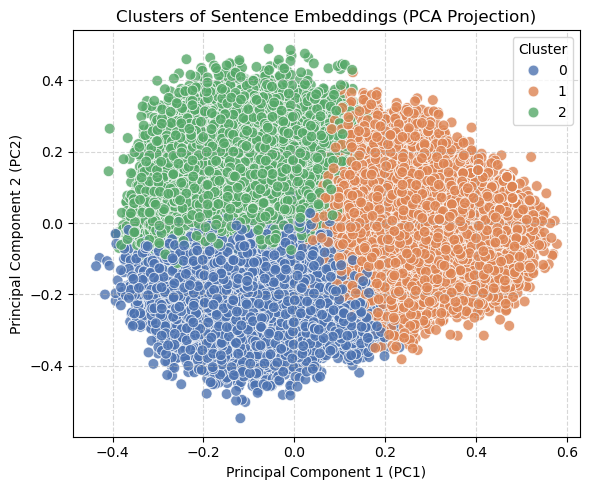

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.scatterplot(
    data=temp_df,          
    x="PC1", 
    y="PC2", 
    hue="Labels",          
    palette="deep",
    s=60,                  
    alpha=0.8               
)

plt.title("Clusters of Sentence Embeddings (PCA Projection)", fontsize=12)
plt.xlabel("Principal Component 1 (PC1)", fontsize=10)
plt.ylabel("Principal Component 2 (PC2)", fontsize=10)
plt.legend(title="Cluster", title_fontsize=10, fontsize=10, loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

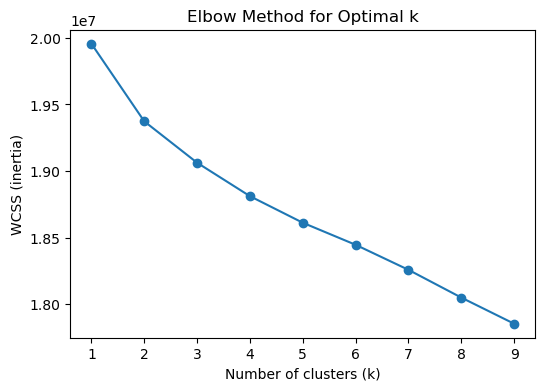

In [41]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)  # inertia_ = WCSS

plt.figure(figsize=(6,4))
plt.plot(range(1,10), wcss, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS (inertia)")
plt.title("Elbow Method for Optimal k")
plt.show()

In [42]:
from kneed import KneeLocator

K = range(1, 10)
kneedle = KneeLocator(K, wcss, curve='convex', direction='decreasing')
elbow_k = kneedle.elbow
print("Optimal k =", elbow_k)

Optimal k = 3


In [44]:
from sklearn.metrics import silhouette_score

k_values = range(2, 6)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, Silhouette Score={score:.3f}")

k=2, Silhouette Score=0.032
k=3, Silhouette Score=0.025
k=4, Silhouette Score=0.023
k=5, Silhouette Score=0.021
